# Kvantuminformatika és -kommunikáció

## Kvantuminformatikai segédprogramok
### Általános tudnivalók

Ezen a gyakorlaton a kvantumáramkörök tervezésével és tesztelésével fogunk foglalkozni. Ehhez a [Qiskit](https://qiskit.org/) python-os könyvtárat és a [Jupyter Notebook](https://jupyter.org/)-ot fogjuk használni.

A gyakorlat elvégzéshez szükséges a Python programozási nyelv ismerete, de ha valaki esetleg még nem használta, azzal sincsen semmi probléma. A feladatok megoldásához szükséges lépéseket közösen át fogjuk beszélni.

Ha valaki saját gépen szeretné elvégezni a mérést, akkor fel kell telepíteni egy Python-t, a Jupyter-t és a Qiskit-et. Az utolsó kettőt `pip` segítségével a következő módon lehet telepíteni egy már működő python installációhoz: 

```
pip install notebook
pip install qiskit[visualization]
pip install qiskit-ibm-runtime
pip install qiskit-aer
```

Ezután indítsuk el a Jupyter-t a `jupyter notebook` paranccsal.

## 1. Ismerkedés a Bloch gömbbel

A Bloch gömbön történő mozgást [ezen oldal](https://bits-and-electrons.github.io/bloch-sphere-simulator/) segítségével fogjuk megvizsgálni. A gömbön sárgával jelölt vektor mutatja az aktuális állapotot, melyet a jobb oldalt található kapuk segítségével tudunk módosítani. Egy kapu használatakor az új állapotba való áttérést egy animációval mutatja be az oldal, így legyünk türelmesek, amíg az véget nem ér (ekkor a vezérléshez használt gombok nem használhatóak). A gömb az egér segítségével forgatható.

### 1.1. feladat - A Pauli kapuk hatásának vizsgálata

Állítsuk be az állapotot a Z tengely irányára (ez az alapállapot) majd hajtsuk végre az X Pauli operátort. Mi történik az állapottal?

Hajtsuk végre ismét az X operátort. Hová került az állapot? Mit tudunk elmondani ez alapján az X kapuról?

Végezzük el ismét ezt a két lépést, de most állítsuk az állapotot elöször az X tengely irányába. (Ehhez az alapállapotból nyomjuk meg a $P_{Y^{\frac{1}{2}}}$ gombot.)  Mit tapasztalunk?

### 1.2. feladat - A Hadamard kapu vizsgálata

Állítsuk ismét alapállapotba a vektort majd hajtsuk végre a H kaput. Mik az így kapott vektor valószínűségi együtthatói? Megfelel annak, amit vártunk?

Mi történik ha még egyszer végrehajtuk a H kaput?

Az X és H kapuk kétszeri végrehajtása során kapott eredmény egybevág a tanultakkal?

## 2. Egyszerű kvantumos áramkörök a Qiskit-tel

### Áramkör létrehozása, kapuk elhelyezése

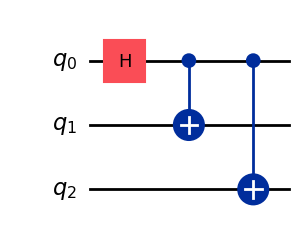

In [1]:
from qiskit import QuantumCircuit

# Egy áramkört a QuantumCircuit példányosításával tudunk létrehozni.
# A konstruktor paraméterének megadható, hogy mennyi qubit legyen az áramkörben. A qubit-ekhez indexek is tartoznak, melyek 0-tól indulnak.
qc = QuantumCircuit(3)

# Ha szeretnénk hozzáadni egy kaput az áramkörhöz, akkor azt az áramkör objektum megfelelő függvényével tudjuk megtenni.
# pl. Ha egy H kaput szeretnénk a nullás indexű qubit-re tenni, akkor azt így valósíthatjuk meg.
qc.h(0)

# Lehetőségünk van irányított kapukat is elhelyezni. Ekkor az első paraméter a kontrollbit indexe, míg a második a célbithez tartozó.
qc.cx(0,1)
qc.cx(0,2)

# Az áramkört meg is tudjuk jeleníti, ezzel ellenőrizhető, hogy azt kaptuk, amire gondoltunk.
qc.draw("mpl")

# A draw függvény paraméter egy string, amivel megadható a kimenete formátuma. Pár érdekes paraméter: "text", "latex" és "mpl" (ez az alapértelmezett).

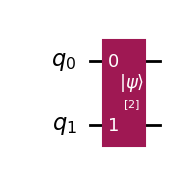

In [2]:
# Az áramkör inicializására is van lehetőség
qc = QuantumCircuit(2)

qc.initialize(2)

qc.draw('mpl')

### Áramkör futtatása és az eredmény feldolgozás, vizualizálása

In [3]:
# Miután létrehoztuk az áramkört, természetesen szeretnénk használni is. Ebben segítenek a backend-ek, melyek végrehajtják az áramkört.
# Több backend is létezik. Van, amelyik egy ideális, hibamentes kvantumszámítógépet valósít meg, de van olyan is, melyben megtalálható egy zajmodell.
# Mindegyik backend-et az Aer.get_backend() hívással tudjuk elérni paraméterként megadva a backend nevét.
from qiskit_aer import Aer

In [4]:
# A legegyszerűbb ilyen backend a statevector_simulator, mellyel a rendszer kvantumos állapotvektorát tudjuk nyomonkövetni a végrehajtás során. Azaz itt "nem jön létre" klasszikus adat.
backend = Aer.get_backend("statevector_simulator")

# Egy áramkör futtatása minden backend-nél azonos folyamot. Létrehozunk egy job objektumot, mely magát a szimulációt tartalmazza. Ezt a backend run függvényével tehetjük meg.
# Ez egy aszinkron folyamat, azaz a háttérben elindul és nem blokkolja a főszálat. Az eredményt a result függvénnyel tudjunk lékérni, ami viszont blokkoló hívás.
job = backend.run(qc)
result = job.result() # Blokkoló hívás!

# A statevector_simulator eredményét a result.get_statevector függvénnyel tudjuk kinyerni megadva az áramkört paraméterként.
outputstate = result.get_statevector(qc)
print(outputstate)

Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


In [5]:
# Az állapotvektor kiírására több lehetőség is adott.
from qiskit.visualization import array_to_latex, plot_bloch_multivector

array_to_latex(outputstate) # Latex-es kiírás

<IPython.core.display.Latex object>

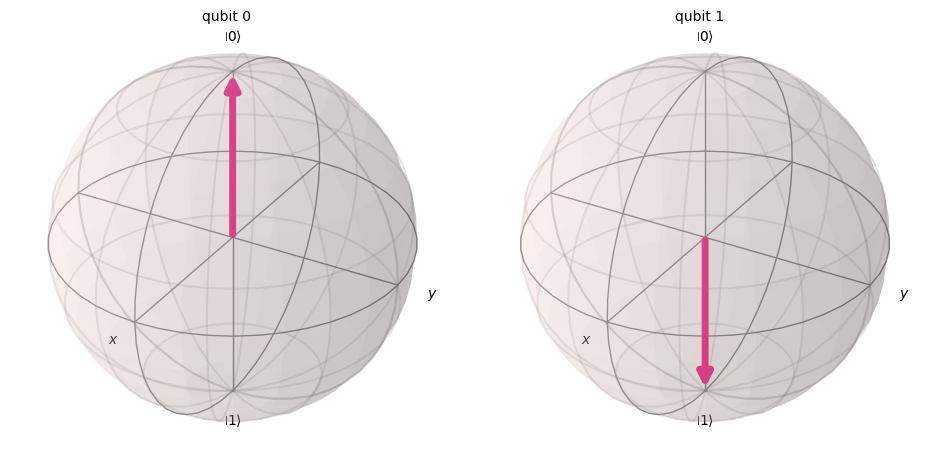

In [6]:
plot_bloch_multivector(outputstate)

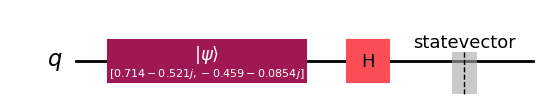

In [7]:
# Áramkör inicializálás egy állapotvektorral.
from qiskit.quantum_info import Statevector, random_statevector

state = random_statevector(2)

qc = QuantumCircuit(1)
qc.initialize(state, 0)
qc.h(0)
qc.save_statevector()
qc.draw("mpl")

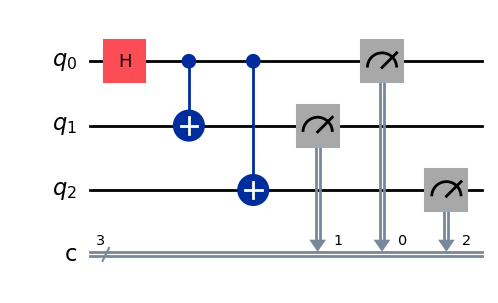

In [8]:
# A legtöbb esetben természetesen úgy szeretnénk szimulálni az áramkört, hogy a végén klasszikus információt kapjunk.
# Ebben segít többek között a qasm_simulator és az aer_simulator backend.

# A klasszikus információhoz viszont elengedhetetlen a mérés elhelyezése. Ahhoz, hogy el tudjuk tárolni a klasszikus információt egy klasszikus regiszterre van szükség.
# Hozzuk létre újra az áramkört, de most adjunk hozzá 3 klasszikus bitet, melyek a 3 qubit mérési eredményeit fogják felvenni.
# A második paraméter a klasszikus bitek száma.
qc = QuantumCircuit(3,3)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)

# A measure függvény szolgál a mérések elhelyezésére, melynek első paraméter a mérni kívánt qubitek listája, a második a mérési eredményeket tároló klasszikus bitek listája.
qc.measure(range(3), range(3))
qc.draw("mpl")

In [9]:
# Próbáljuk ki az aer_simulator-t
backend = Aer.get_backend("aer_simulator")
# Szimuláció esetén megadható, hogy egy job-ban hányszor fusson az áramkört. Erre szolgál a shots paraméter.
result = backend.run(qc, shots=100).result()

# A mérési eredményeket a result.get_counts függvénnyel tudjuk elérni.
counts = result.get_counts()
print(counts)

{'000': 51, '111': 49}


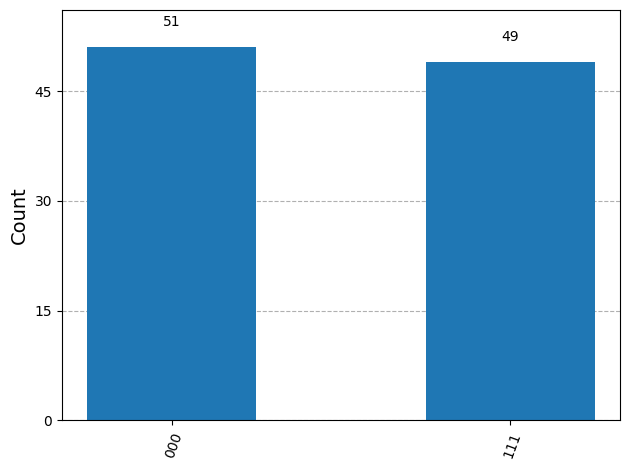

In [10]:
# A mérési eredményeket jobban is tudjuk szemlélteni.
from qiskit.visualization import plot_histogram

plot_histogram(counts)

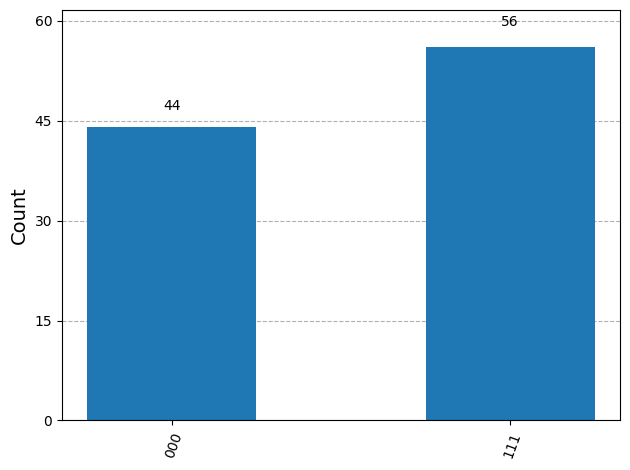

In [11]:
# A másik sokszor használt backend a qasm_simulator.
# Használatakor viszont nem lehet egyszerűen odadni az áramkört, hanem át kell alakítani, hogy a qasm_simulator által is értelmezhető formátumba kerüljün.
# Ebben segít a transpile függvény.
from qiskit import transpile

backend = Aer.get_backend("qasm_simulator")
counts = backend.run(transpile(qc, backend), shots=100).result().get_counts()

plot_histogram(counts)

In [12]:
# Állapotvektor lekérése

backend = Aer.get_backend("aer_simulator")

state = random_statevector(2)

qc = QuantumCircuit(1)
qc.initialize(state, 0)
qc.h(0)
qc.save_statevector()


result_state = backend.run(qc).result().get_statevector()
print(result_state)

Statevector([-0.56300951+0.73697381j,  0.27649769-0.25187086j],
            dims=(2,))


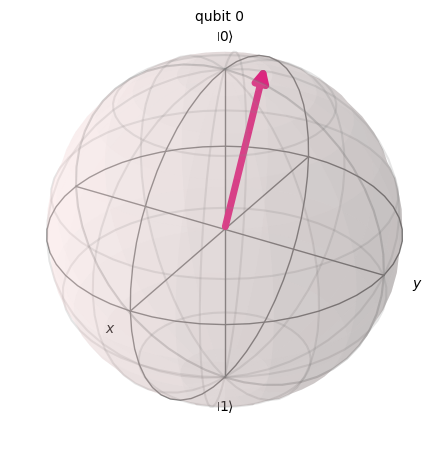

In [13]:
plot_bloch_multivector(result_state)

### 2.1. A Hadamard kapuk vizsgálata

#### 2.1.1. A H kapu egyszeri alkalmazása

Készítsük el a lenti áramkört és futtassuk egyszer!

![A H kapu egyszeri használata majd mérés](h_gate_simple.png)

Az elvárt eredményt kaptuk?

Mi történik akkor, ha 1000-szer futtatjuk le a szimulációt?

Mi történik, ha kétszer mérünk egymás után?

Azaz módosítsuk a fenti áramkört, hogy a következőt kapjuk:

![Dupla mérés](double_mes.png)

Mit árul ez el a mérés tulajdonságairól?

#### 2.1.2. A H kapu kétszeri alkalmazása

Hozzuk létre a következő áramkört:

![H kapu kétszer egymás után](double_h_gate.png)

Megfelelő eredményt kaptunk? Egybevág a Bloch gömbnél megfigyeltekkel?

#### 2.1.3 Egy nehezítés beiktatása

Módosítsuk a fenti áramkört a következőre:

![Egy lehallgató megjelenése](eve_enters.png)

Változott a korábbi kimenethez képest a tesztelés eredménye?

#### 2.1.4. Tetszőleges állapot előállítása

Készítsünk egy áramkört, amely a $|0\rangle$ állapotból előállítja a $\alpha|0\rangle + \beta e^{i\theta}|1\rangle$ állapotot! Az $\alpha, \beta$ változók pozitív valós számok és $\sqrt{1-\alpha^2} = \beta$. A $\theta$ pedig egy tetszőleg valós szám.

A megoldáshoz használjuk fel a következő kapukat:

![Forgatást megvalósító kapuk](rotation_gates.png)

**FONTOS: Az $R_1$ kapu a Qiskit-ben a `P` kapunak feleltethető meg.**

Tipp: Készítsük el először csak a  $\alpha|0\rangle + \beta |0\rangle$ állapotot!

## 3. Az összefonodás

### A Bell-állapotok

Rövid összefoglaló a Bell-állapotok létrehozásáról:

![A Bell-állapotok előállítása](bell_states.png)

### Bell-állaptok előállítása Qiskit-tel

Készítsünk egy áramkört, ami korábban megismert `initialize` függvény segítségével előállít egy tetszőleges Bell-állapotot!

# 4. Állapotok cseréje

Szeretnénk létrehozni egy olyan $U$ unitér transzformációt, ami két kvantumállapotot megcserél, azaz:

$$
U(|\theta\rangle \otimes |\psi\rangle) = |\psi\rangle \otimes |\theta\rangle
$$

Hogyan fog kinézni az $U$-hoz tartozó mátrix? Induljunk ki abból, hogy hogyan hat a kétbites bázisokra.

Az $U$ transzformáció a $|00\rangle$-t a $|00\rangle$-be, a $|01\rangle$-t a $|10\rangle$-be, a $|10\rangle$-t a $|01\rangle$-be, míg az $|11\rangle$-t a $|11\rangle$-be mozgatja. Összefoglalva:

$$
\begin{align}
U|00\rangle &= |00\rangle \\
U|01\rangle &= |10\rangle \\
U|10\rangle &= |01\rangle \\
U|11\rangle &= |11\rangle
\end{align}
$$

Ebből a mátrixot is könnyen megkaphatjuk:

$$
U = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

De hogyan tudjuk ezt kapukkal megvalósítani?

Klasszikus adatok cseréjére több lehetőség is adott. Az egyik legismeretebb a következő:
```python
t = a
a = b
b = t
```

De lehet egy kicsit trükközni is:
```
a ^= b
b ^= a
a ^= b
```

Itt a `a ^= b` a bitenkénti `XOR` (modulo 2 összeadást) jelenti. Ez miért működik?

```python
a ^= b # Ezután a = a ^ b
b ^= a # Ezután b = b ^ (a ^ b)
a ^= b # Ezután a = (a ^ b) ^ (b ^ (a ^ b))
```

Azaz a legvégén: `b = b ^ (a ^ b) = a` és `a = (a ^ b) ^ (b ^ (a ^ b)) = b`, így a két változó értéke tényleg felcserélődött. Sőt az átalakítás visszafordítható.

Az `x_1 XOR x_2` operáció két bitre úgyis értelmezhető, hogy az `x_1` értéke 1, akkor negáljuk az `x_2`-t.

Ez pedig pontosan a $CNOT$ kapu viselkedését írja le. Ezt felhasználva az $U$ transzformáció tehát:

<center><img src="swap_with_cnots.jpg"></center>

Az $U$ utasítás neve pedig $SWAP$ és a jelölése:

<center><img src="swap_rep.png" style="width: 10%"></center>

Akit bővebben érdekel a $SWAP$ operációt, annak ajánlom [ezt az oldalt](https://algassert.com/post/1717).

Ellenőrizzük, hogy tényleg az elvárt transzformációt kapjuk: